# Browse a Niyān dataset and preview medical image files

This example builds a small, read-only file explorer with Niyān's `fsspec` filesystem. Double-click a directory to enter it or an `.ndpi` file to render the smallest stored pyramid level as a thumbnail. The browser pins the requested branch or tag to one exact Git commit before it lists any files.

The NDPI preview is streamed through a seekable Niyān file handle. `tifffile` seeks to TIFF metadata and the selected pyramid level, so it does not need to download the complete whole-slide image first. This is intentionally a compact example rather than a deep-zoom viewer.

> **Privacy:** The example here is drawn from a publically available WSI dataset. Nontheless, this notebook displays only a small set of structural fields and does not print TIFF tags or credentials. Use an appropriately protected Jupyter environment when viewing medical data.

## Environment

Use Python 3.12 or newer and install the notebook-only dependencies in your analysis environment:

```shell
python -m pip install niyan ipywidgets ipyevents "tifffile[codecs]" pillow
```

Authenticate beforehand with `niyan auth login`, or place a short-lived access token in the `NIYAN_TOKEN` environment variable. Do not paste a token into this notebook.

In [7]:
from html import escape
from io import BytesIO
import os
from pathlib import PurePosixPath
from typing import Any, BinaryIO

import fsspec
from IPython.display import display
from ipyevents import Event
import ipywidgets as widgets
import numpy as np
from PIL import Image
import tifffile


# Edit these non-secret values for your installation and dataset.
NIYAN_HOST = "http://localhost:8000"
DATASET = "group/dataset"
REVISION = "main"

# Smaller blocks make this demonstration's range behavior easier to observe.
BLOCK_SIZE = 1024 * 1024
MAX_THUMBNAIL_SIZE = (1024, 768)

In [4]:
class CountingReader:
    """Count bytes returned to a consumer of a seekable binary stream."""

    def __init__(self, raw: BinaryIO) -> None:
        """Wrap an open binary stream without taking ownership of it.

        Parameters
        ----------
        raw : BinaryIO
            Seekable binary stream supplied by fsspec.
        """

        self.raw = raw
        self.bytes_read = 0

    def read(self, size: int = -1) -> bytes:
        """Read bytes and add their length to the consumer-visible total."""

        content = self.raw.read(size)
        self.bytes_read += len(content)
        return content

    def readinto(self, buffer: bytearray) -> int:
        """Fill a writable buffer and count the returned bytes."""

        count = self.raw.readinto(buffer)
        self.bytes_read += count or 0
        return count

    def seek(self, offset: int, whence: int = 0) -> int:
        """Move to a byte offset in the wrapped stream."""

        return self.raw.seek(offset, whence)

    def tell(self) -> int:
        """Return the current byte offset."""

        return self.raw.tell()

    def seekable(self) -> bool:
        """Return whether the wrapped stream supports seeking."""

        return self.raw.seekable()

    def readable(self) -> bool:
        """Return whether the wrapped stream supports reading."""

        return self.raw.readable()

    def __getattr__(self, name: str) -> Any:
        """Delegate other file attributes to the wrapped stream."""

        return getattr(self.raw, name)


def format_size(size: int) -> str:
    """Format a byte count using compact binary units."""

    value = float(size)
    for unit in ("B", "KiB", "MiB", "GiB", "TiB"):
        if value < 1024 or unit == "TiB":
            return f"{value:.0f} {unit}" if unit == "B" else f"{value:.1f} {unit}"
        value /= 1024
    raise AssertionError("unreachable")


def image_to_png(array: np.ndarray) -> bytes:
    """Convert a TIFF level to a bounded display-ready PNG."""

    pixels = np.squeeze(np.asarray(array))
    while pixels.ndim > 3:
        pixels = pixels[pixels.shape[0] // 2]
    if pixels.ndim == 3 and pixels.shape[-1] not in (3, 4) and pixels.shape[0] in (3, 4):
        pixels = np.moveaxis(pixels, 0, -1)
    if pixels.ndim not in (2, 3) or (pixels.ndim == 3 and pixels.shape[-1] not in (3, 4)):
        raise ValueError(f"The selected TIFF level has an unsupported display shape: {pixels.shape}.")

    if pixels.dtype != np.uint8:
        finite = pixels[np.isfinite(pixels)]
        if not finite.size:
            raise ValueError("The selected TIFF level contains no finite pixel values.")
        low, high = np.percentile(finite, (1, 99))
        if high <= low:
            high = low + 1
        pixels = np.clip((pixels.astype(np.float32) - low) * (255 / (high - low)), 0, 255).astype(np.uint8)

    image = Image.fromarray(pixels)
    image.thumbnail(MAX_THUMBNAIL_SIZE)
    output = BytesIO()
    image.save(output, format="PNG")
    return output.getvalue()


def series_area(series: Any) -> int:
    """Return the pixel area of a TIFF series' X and Y axes."""

    axes = str(series.axes)
    if "X" in axes and "Y" in axes:
        return int(series.shape[axes.index("X")]) * int(series.shape[axes.index("Y")])
    return int(np.prod(series.shape[-2:]))

In [5]:
class NiyanNdpiExplorer:
    """Render a two-pane browser for one immutable Niyān dataset revision."""

    def __init__(self, filesystem: Any, resolved_commit: str) -> None:
        """Create the widgets and list the dataset root.

        Parameters
        ----------
        filesystem : fsspec.AbstractFileSystem
            Niyān filesystem already configured with an exact commit.
        resolved_commit : str
            Exact Git commit used for every browser operation.
        """

        self.fs = filesystem
        self.resolved_commit = resolved_commit
        self.current_path = ""
        self.entries: list[dict[str, Any]] = []

        self.location = widgets.HTML()
        self.listing = widgets.HTML(layout=widgets.Layout(height="480px", overflow="auto"))
        self.status = widgets.HTML()
        self.viewer_details = widgets.HTML(
            "<p style='color:#71717a'>Double-click an <code>.ndpi</code> file to preview it.</p>"
        )
        self.viewer_image = widgets.Image(format="png", layout=widgets.Layout(max_width="100%"))

        self.up_button = widgets.Button(description="Up", icon="level-up-alt", disabled=True)
        self.refresh_button = widgets.Button(description="Refresh", icon="refresh")
        self.up_button.on_click(self._go_up)
        self.refresh_button.on_click(self._refresh_clicked)

        self.listing_events = Event(source=self.listing, watched_events=["dblclick"])
        self.listing_events.on_dom_event(self._open_entry)

        left = widgets.VBox(
            [widgets.HBox([self.up_button, self.refresh_button]), self.location, self.listing, self.status],
            layout=widgets.Layout(width="38%", min_width="320px", border="1px solid #d4d4d8", padding="12px"),
        )
        right = widgets.VBox(
            [widgets.HTML("<h3 style='margin-top:0'>NDPI preview</h3>"), self.viewer_details, self.viewer_image],
            layout=widgets.Layout(width="62%", min_width="420px", border="1px solid #d4d4d8", padding="12px"),
        )
        self.widget = widgets.HBox([left, right], layout=widgets.Layout(width="100%", gap="12px", align_items="stretch"))
        self.refresh()

    def refresh(self) -> None:
        """List and render the current repository directory."""

        self._set_busy(True, "Loading directory…")
        try:
            entries = self.fs.ls(self.current_path, detail=True)
            self.entries = sorted(entries, key=lambda item: (item["type"] != "directory", PurePosixPath(item["repository_path"]).name.casefold()))
            self._render_listing()
            self.status.value = f"<small>{len(self.entries)} entries · commit <code>{escape(self.resolved_commit[:12])}</code></small>"
        except Exception as error:
            self.entries = []
            self.listing.value = ""
            self.status.value = self._error_html(error)
        finally:
            self._set_busy(False)

    def _render_listing(self) -> None:
        """Render directory entries as double-clickable HTML buttons."""

        rows = []
        for index, entry in enumerate(self.entries):
            name = PurePosixPath(entry["repository_path"]).name
            is_directory = entry["type"] == "directory"
            icon = "📁" if is_directory else ("🔬" if name.casefold().endswith(".ndpi") else "📄")
            size = "—" if is_directory else format_size(int(entry["size"]))
            muted = " niyan-entry-muted" if not is_directory and not name.casefold().endswith(".ndpi") else ""
            label = escape(f"{icon}  {name}                                      {size}")
            rows.append(f"<button id='niyan-entry-{index}' class='niyan-entry{muted}' title='{escape(entry['repository_path'])}'>{label}</button>")
        empty = "<p style='color:#71717a;padding:8px'>This directory is empty.</p>" if not rows else ""
        self.listing.value = """
        <style>
        .niyan-entry { display:block; width:100%; padding:9px 10px; border:0; border-bottom:1px solid #e4e4e7; background:transparent; color:inherit; text-align:left; font:13px ui-monospace, SFMono-Regular, Menlo, monospace; white-space:pre; cursor:pointer; overflow:hidden; text-overflow:ellipsis; }
        .niyan-entry:hover { background:#eef2ff; }
        .niyan-entry-muted { color:#71717a; }
        </style>
        """ + "".join(rows) + empty
        display_path = "/" + self.current_path if self.current_path else "/"
        self.location.value = f"<p><strong>Path:</strong> <code>{escape(display_path)}</code></p><small>Double-click to open</small>"
        self.up_button.disabled = not self.current_path

    def _open_entry(self, event: dict[str, Any]) -> None:
        """Open the directory or NDPI file targeted by a double click."""

        target_id = str(event.get("target", {}).get("id", ""))
        if not target_id.startswith("niyan-entry-"):
            return
        try:
            entry = self.entries[int(target_id.removeprefix("niyan-entry-"))]
        except (ValueError, IndexError):
            return
        if entry["type"] == "directory":
            self.current_path = entry["repository_path"]
            self.refresh()
        elif entry["repository_path"].casefold().endswith(".ndpi"):
            self._preview_ndpi(entry)
        else:
            self.status.value = "<small>This example previews only <code>.ndpi</code> files.</small>"

    def _preview_ndpi(self, entry: dict[str, Any]) -> None:
        """Stream and display the smallest pyramid level of one NDPI file."""

        repository_path = entry["repository_path"]
        self._set_busy(True, f"Reading {PurePosixPath(repository_path).name}…")
        self.viewer_image.value = b""
        try:
            with self.fs.open(repository_path, "rb", block_size=BLOCK_SIZE) as remote_file:
                counted_file = CountingReader(remote_file)
                with tifffile.TiffFile(counted_file) as slide:
                    if not slide.series:
                        raise ValueError("The NDPI file contains no image series.")
                    series = max(slide.series, key=series_area)
                    levels = list(series.levels)
                    selected_level = levels[-1]
                    pixels = selected_level.asarray(maxworkers=1)
                    level_shape = tuple(selected_level.shape)
                bytes_read = counted_file.bytes_read

            self.viewer_image.value = image_to_png(pixels)
            file_size = int(entry["size"])
            fraction = (100 * bytes_read / file_size) if file_size else 0
            self.viewer_details.value = f"""
            <p><strong>{escape(PurePosixPath(repository_path).name)}</strong></p>
            <dl>
              <dt>Logical file size</dt><dd>{format_size(file_size)}</dd>
              <dt>Pyramid levels</dt><dd>{len(levels)}</dd>
              <dt>Displayed level shape</dt><dd><code>{escape(str(level_shape))}</code></dd>
              <dt>Bytes returned to tifffile</dt><dd>{format_size(bytes_read)} ({fraction:.2f}% of the logical file)</dd>
              <dt>Resolved commit</dt><dd><code>{escape(self.resolved_commit)}</code></dd>
            </dl>
            <small>Network transfer can be somewhat larger because the fsspec reader fetches bounded readahead blocks.</small>
            """
            self.status.value = "<small>Preview ready.</small>"
        except Exception as error:
            self.viewer_details.value = self._error_html(error)
            self.status.value = "<small>Preview failed.</small>"
        finally:
            self._set_busy(False)

    def _go_up(self, _: widgets.Button) -> None:
        """Navigate to the current directory's parent."""

        parent = str(PurePosixPath(self.current_path).parent)
        self.current_path = "" if parent == "." else parent
        self.refresh()

    def _refresh_clicked(self, _: widgets.Button) -> None:
        """Refresh the current directory at the already pinned commit."""

        self.refresh()

    def _set_busy(self, busy: bool, message: str = "") -> None:
        """Update control availability and an optional progress message."""

        self.up_button.disabled = busy or not self.current_path
        self.refresh_button.disabled = busy
        if message:
            self.status.value = f"<small>{escape(message)}</small>"

    @staticmethod
    def _error_html(error: Exception) -> str:
        """Return escaped, compact HTML for a public client exception."""

        return f"<p style='color:#b91c1c'><strong>{escape(type(error).__name__)}</strong>: {escape(str(error))}</p>"

## Connect and browse

The first metadata request resolves `REVISION` to an exact commit. A new filesystem is then constructed with that commit, keeping every subsequent listing and preview immutable even if the branch moves.

In [6]:
token = os.environ.get("NIYAN_TOKEN")
requested_filesystem = fsspec.filesystem(
    "niyan",
    host=NIYAN_HOST,
    dataset=DATASET,
    revision=REVISION,
    token=token,
    block_size=BLOCK_SIZE,
)
root_info = requested_filesystem.info("")
resolved_commit = root_info["resolved_commit"]

filesystem = fsspec.filesystem(
    "niyan",
    host=NIYAN_HOST,
    dataset=DATASET,
    revision=resolved_commit,
    token=token,
    block_size=BLOCK_SIZE,
)
explorer = NiyanNdpiExplorer(filesystem, resolved_commit)
display(explorer.widget)

In case the above widget is not showing up properly on GitHub, here's a screenshot showing the widget once the notebook is running in Jupyter:

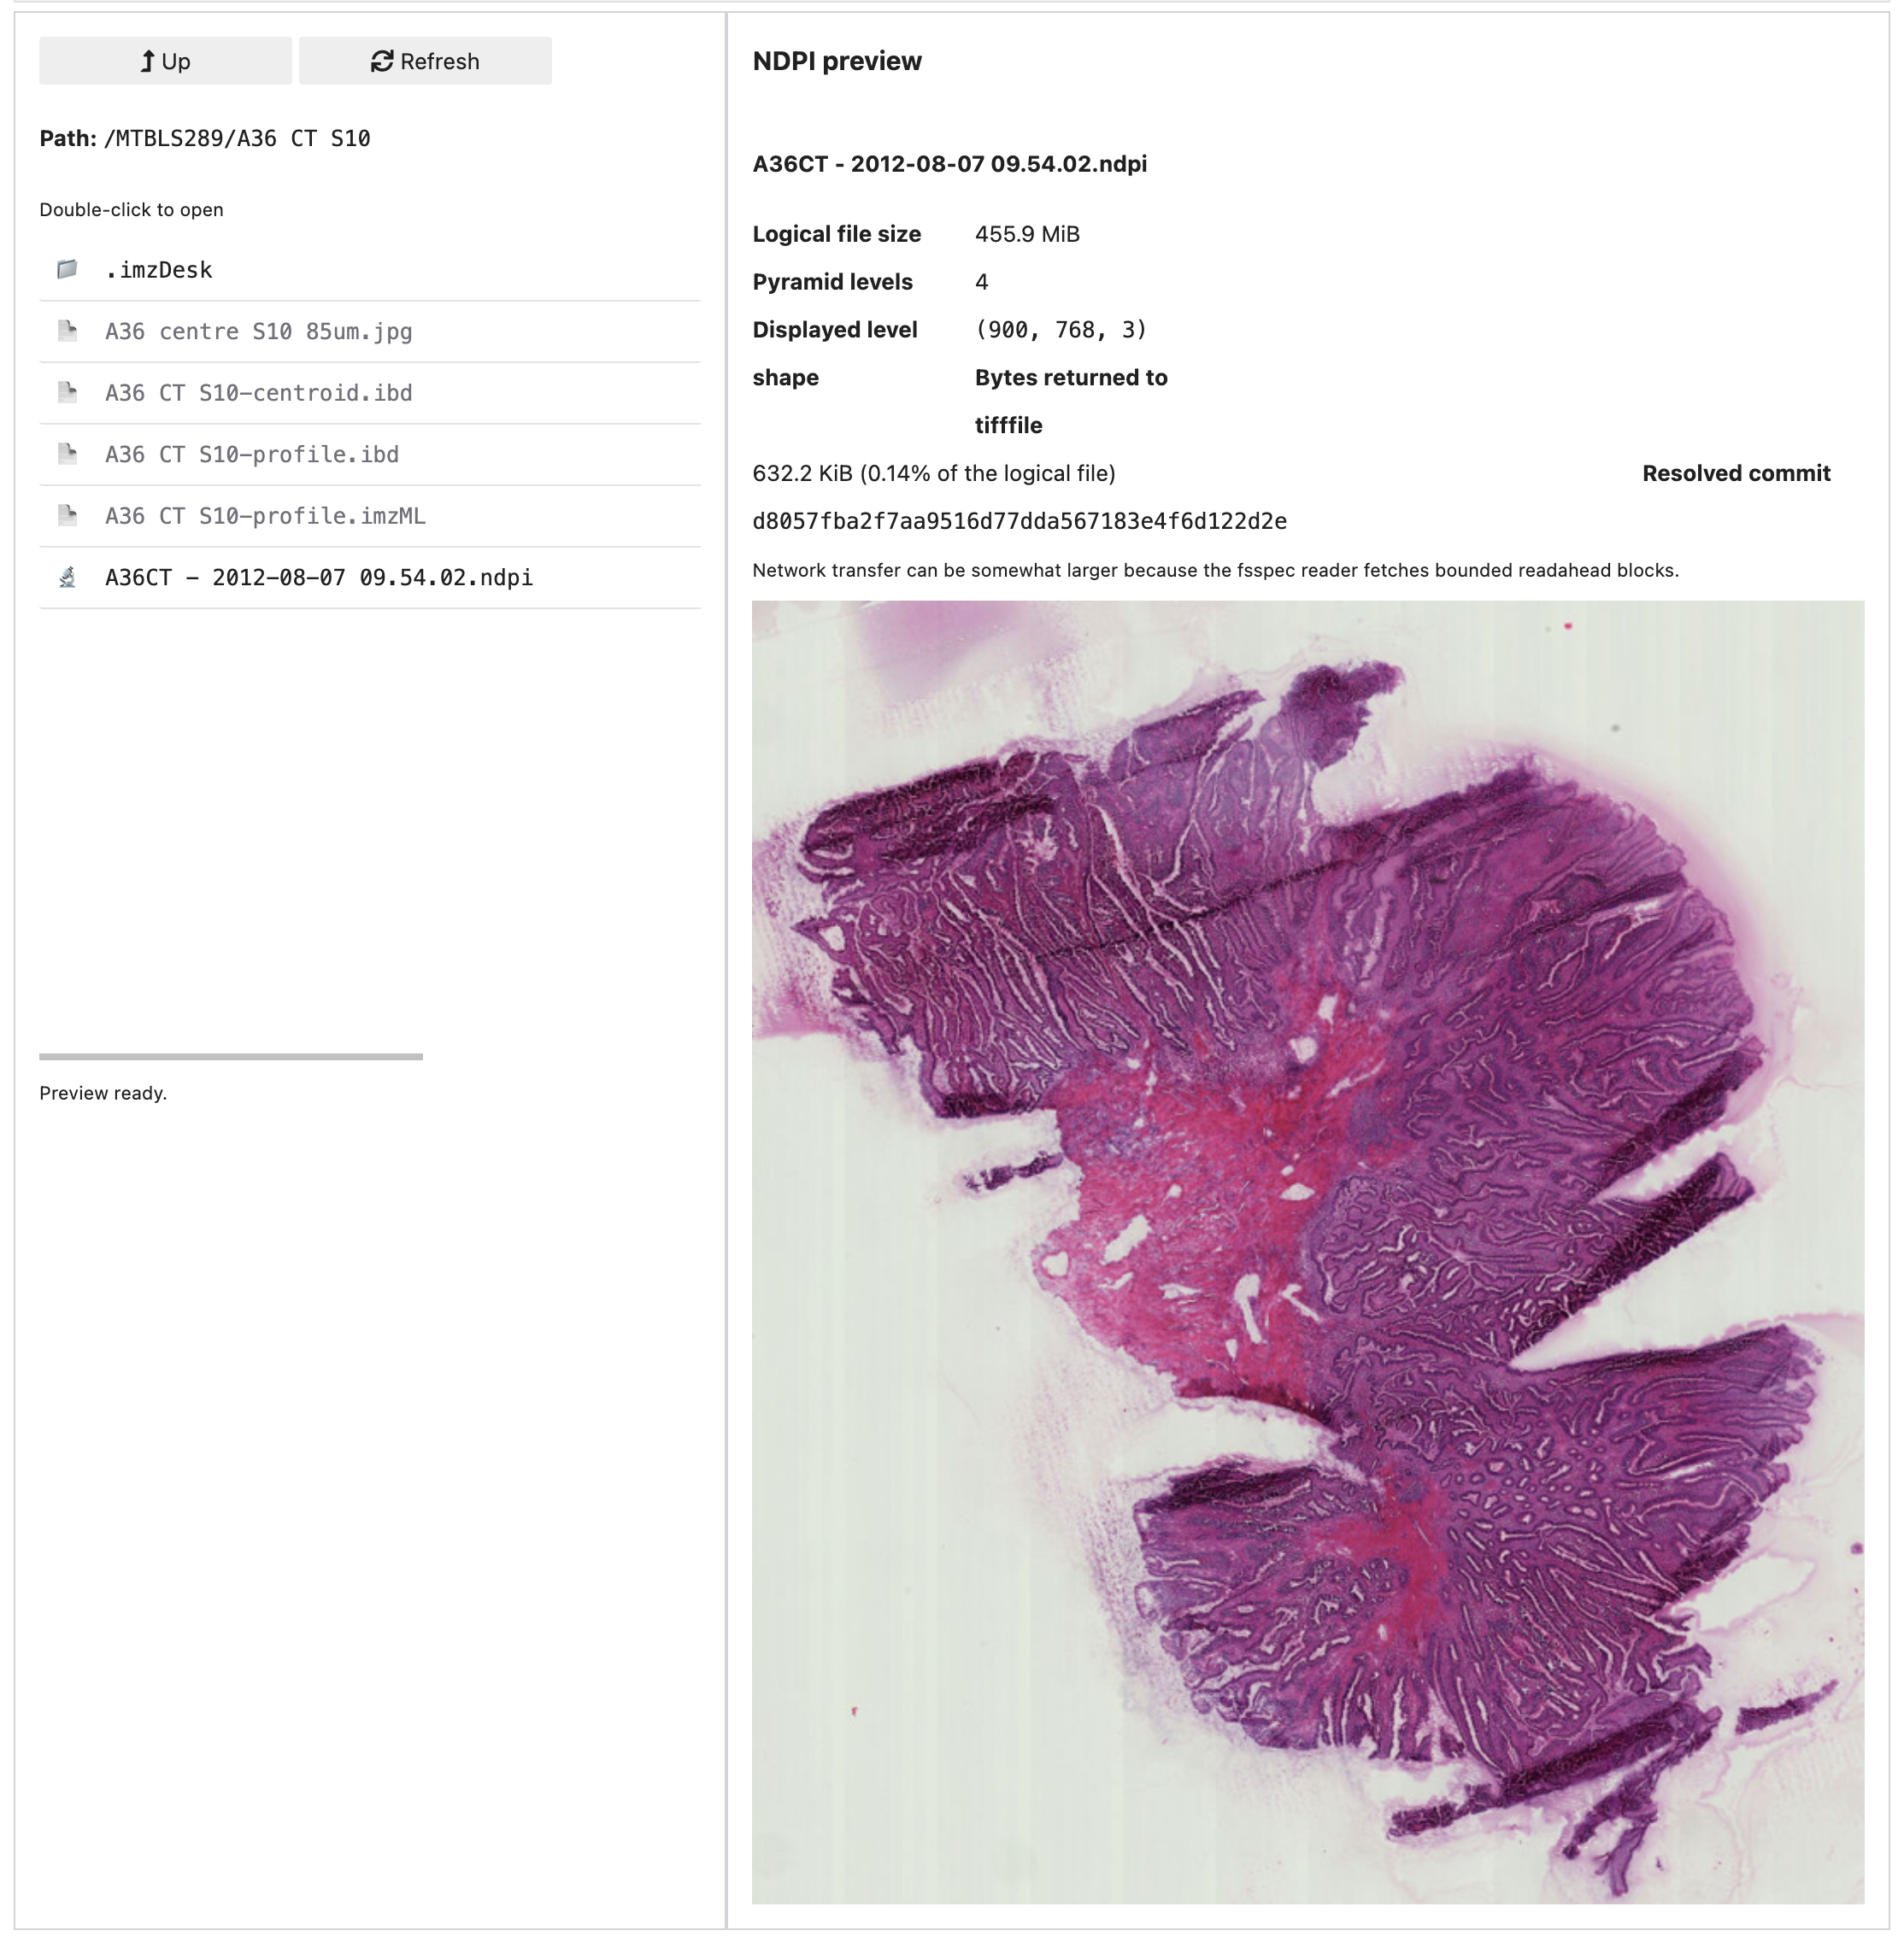